in this code, we have reproduced the results of mblip on the languages we chose to use on our report. azerbaijani xm3600 data also is used here.

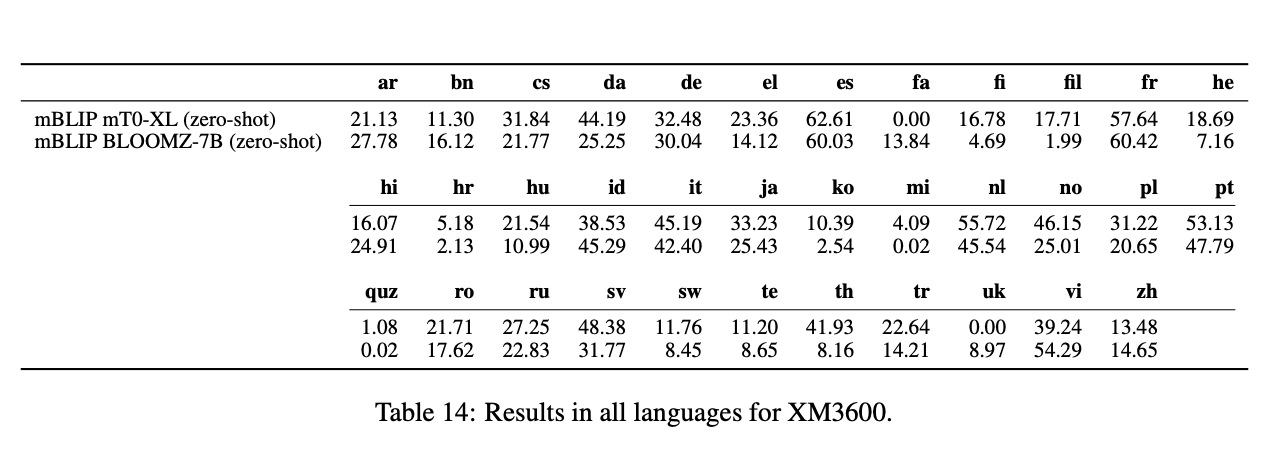

In [3]:
!pip install transformers==4.46.0 datasets accelerate bitsandbytes
!pip install pycocoevalcap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 4.0 MB/s eta 0:00:00
Reason for being yanked: This version unfortunately does not work with 3.8 but we did not drop the support yet
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 113.7 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.7.1
    Uninstalling huggingface_hub-1.7.1:
      Successfully uninstalled huggingface_hub-1.7.1
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      S

In [4]:
import torch
from transformers import Blip2ForConditionalGeneration, AutoProcessor

model_id = "Gregor/mblip-mt0-xl"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on: {device}")

if device == "cuda":
    model = Blip2ForConditionalGeneration.from_pretrained(
        model_id, torch_dtype=torch.bfloat16, device_map="auto"
    )
else:
    print("WARNING: CPU will be extremely slow (~14h for 7 langs).")
    model = Blip2ForConditionalGeneration.from_pretrained(model_id)

processor = AutoProcessor.from_pretrained(model_id)
print("Model loaded.")

Running on: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/9.96G [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/324 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/16.3M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/74.0 [00:00<?, ?B/s]

Model loaded.


In [3]:
EVAL_LANGS = ["en", "de", "uk", "ar", "tr", "bn", "vi"]

LANG_NAMES = {
    "en": "English", "de": "German", "uk": "Ukrainian",
    "ar": "Arabic", "tr": "Turkish", "bn": "Bengali", "vi": "Vietnamese",
}

PROMPTS = {
    "en": "Describe the image in English.",
    "de": "Describe the image in German.",
    "uk": "Describe the image in Ukrainian.",
    "ar": "Describe the image in Arabic.",
    "tr": "Describe the image in Turkish.",
    "bn": "Describe the image in Bengali.",
    "vi": "Describe the image in Vietnamese.",
}

print(f"Will evaluate on {len(EVAL_LANGS)} languages: {EVAL_LANGS}")

Will evaluate on 7 languages: ['en', 'de', 'uk', 'ar', 'tr', 'bn', 'vi']


In [5]:
from datasets import load_dataset, Image as HFImage
from tqdm import tqdm


def load_xm3600_split(lang, max_samples=None):
    """Load one language split from XM3600."""
    ds = load_dataset("floschne/xm3600", split=lang)
    ds = ds.map(
        lambda sample: {
            "image_t": [HFImage().decode_example(img) for img in sample["image"]],
        },
        remove_columns=["image"],
        batched=True,
        batch_size=32,
    ).rename_columns({"image_t": "image"})

    if max_samples:
        ds = ds.select(range(min(max_samples, len(ds))))
    return ds


def run_mblip(image, prompt="Describe the image.", max_new_tokens=50):
    """Run mBLIP inference on a single image."""
    inputs = processor(images=image, text=prompt, return_tensors="pt")
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    pixel_values = inputs["pixel_values"]
    input_ids = inputs["input_ids"]
    attention_mask = inputs.get("attention_mask")

    with torch.no_grad():
        vision_outputs = model.vision_model(pixel_values=pixel_values)
        image_embeds = vision_outputs[0]

        query_tokens = model.query_tokens.expand(image_embeds.shape[0], -1, -1)
        image_attn = torch.ones(
            image_embeds.size()[:-1], dtype=torch.long, device=model.device
        )
        query_outputs = model.qformer(
            query_embeds=query_tokens,
            encoder_hidden_states=image_embeds,
            encoder_attention_mask=image_attn,
        )

        lang_inputs = model.language_projection(query_outputs[0])
        lang_attn = torch.ones(
            lang_inputs.size()[:-1], dtype=torch.long, device=model.device
        )

        text_embeds = model.language_model.get_input_embeddings()(input_ids)
        inputs_embeds = torch.cat([lang_inputs, text_embeds], dim=1)

        if attention_mask is not None:
            attention_mask = torch.cat([lang_attn, attention_mask], dim=1)

        outputs = model.language_model.generate(
            inputs_embeds=inputs_embeds,
            attention_mask=attention_mask,
            max_new_tokens=max_new_tokens,
        )

    return processor.decode(outputs[0], skip_special_tokens=True)


def generate_captions_for_dataset(dataset, lang):
    """Generate captions for all images in a dataset split."""
    results = {}
    prompt = PROMPTS[lang]
    for i in tqdm(range(len(dataset)), desc=f"Generating [{lang}]"):
        sample = dataset[i]
        img_id = str(sample["image_id"])
        results[img_id] = run_mblip(sample["image"], prompt=prompt)
    return results


print("Functions ready.")

Functions ready.


In [6]:
from pycocoevalcap.cider.cider import Cider
from pycocoevalcap.tokenizer.ptbtokenizer import PTBTokenizer


def compute_cider(generated, references):
    """Compute CIDEr score (×100) between generated and reference captions."""
    gts = {}
    res = {}
    for img_id in generated:
        if img_id not in references:
            continue
        gts[img_id] = [{"caption": r} for r in references[img_id]]
        res[img_id] = [{"caption": generated[img_id]}]

    tokenizer = PTBTokenizer()
    gts_tok = tokenizer.tokenize(gts)
    res_tok = tokenizer.tokenize(res)

    scorer = Cider()
    score, _ = scorer.compute_score(gts_tok, res_tok)
    return score * 100


print("CIDEr scorer ready.")

CIDEr scorer ready.


In [6]:
import time

MAX_SAMPLES = 1000  # set to None for full XM3600 (~3600 per lang)

all_results = {}

for lang in EVAL_LANGS:
    print(f"\n{'='*60}")
    print(f"Evaluating: {LANG_NAMES[lang]} ({lang})")
    print(f"{'='*60}")

    t0 = time.time()

    # Load dataset
    ds = load_xm3600_split(lang, max_samples=MAX_SAMPLES)
    print(f"  Images: {len(ds)}")

    # Build reference dict
    references = {}
    for sample in ds:
        img_id = str(sample["image_id"])
        refs = sample["captions"]
        if not isinstance(refs, list):
            refs = [refs]
        references[img_id] = refs

    # Generate captions
    generated = generate_captions_for_dataset(ds, lang)

    # Compute CIDEr
    cider = compute_cider(generated, references)

    elapsed = time.time() - t0
    all_results[lang] = {"cider": cider, "n": len(generated), "time": elapsed}

    # Show a sample
    sample_id = list(generated.keys())[0]
    print(f"  CIDEr: {cider:.1f}")
    print(f"  Sample gen: '{generated[sample_id]}'")
    print(f"  Sample ref: '{references[sample_id][0]}'")
    print(f"  Time: {elapsed:.0f}s")

print("\n✓ All evaluations complete!")


Evaluating: English (en)


README.md: 0.00B [00:00, ?B/s]

data/ar-00000-of-00001.parquet:   0%|          | 0.00/185M [00:00<?, ?B/s]

data/bn-00000-of-00001.parquet:   0%|          | 0.00/185M [00:00<?, ?B/s]

data/cs-00000-of-00001.parquet:   0%|          | 0.00/185M [00:00<?, ?B/s]

...

  CIDEr: 8.7
  Sample gen: 'একটি বাগাড়ম্বরের মধ্যে একটি বাগাড়ম্বরের মধ্যে একটি বাগাড়ম্বরের মধ্যে একটি বাগাড়ম্বরের মধ্যে একটি বাগাড়ম্বরের মধ্যে'
  Sample ref: 'জঙ্গলের মদহে দুইটি বাদামী ও কালো রঙের মুরগি আছে'
  Time: 1833s

Evaluating: Vietnamese (vi)


Map:   0%|          | 0/3600 [00:00<?, ? examples/s]

  Images: 1000


Generating [vi]: 100%|██████████| 1000/1000 [27:51<00:00,  1.67s/it]


  CIDEr: 40.4
  Sample gen: 'Hai con gà đang đi bộ trên một con đường gỗ.'
  Sample ref: 'Một con gà trống và một con gà mái đang đi kiếm ăn trong vườn'
  Time: 1695s

✓ All evaluations complete!


In [8]:
print(f"{'Lang':<6} {'Our CIDEr':>12}")
print("-" * 20)
for lang in EVAL_LANGS:
    # Using all_results instead of results and directly accessing 'cider'
    cider_score = all_results[lang]['cider']
    print(f"{lang:<6} {cider_score:>12.1f}")

Lang      Our CIDEr
--------------------
en             77.5
de             30.7
uk             19.5
ar             21.6
tr             20.6
bn              8.7
vi             40.4


In [10]:
import pandas as pd
import numpy as np

# mBLIP paper CIDEr scores (Table 2) for our 7 languages
PAPER_SCORES = {
    "en": 80.20, "de": 32.48, "uk": 00.00,
    "ar": 21.13, "tr": 22.64, "bn": 11.30, "vi": 39.24,
}

rows = []
for lang in EVAL_LANGS:
    r = all_results[lang]
    paper_val = PAPER_SCORES.get(lang, None)
    rows.append({
        "Lang": lang,
        "Name": LANG_NAMES[lang],
        "Our CIDEr": round(r["cider"], 2),
        "Paper CIDEr": paper_val,
        "Diff": round(r["cider"] - paper_val, 2) if paper_val else None,
        "N": r["n"],
        "Time (s)": round(r["time"], 0),
    })

df = pd.DataFrame(rows)
print("=" * 65)
print("  mBLIP CIDEr on XM3600 — Our Results vs Paper")
print("=" * 65)
print(df.to_string(index=False))

our_avg = np.mean([all_results[l]["cider"] for l in EVAL_LANGS])
paper_avg = np.mean([PAPER_SCORES[l] for l in EVAL_LANGS])
total_time = sum(all_results[l]["time"] for l in EVAL_LANGS)

print(f"\nOur avg CIDEr (7 langs): {our_avg:.2f}")
print(f"Paper avg CIDEr (7 langs): {paper_avg:.2f}")
print(f"Total wall time: {total_time/60:.1f} min")

  mBLIP CIDEr on XM3600 — Our Results vs Paper
Lang       Name  Our CIDEr  Paper CIDEr  Diff    N  Time (s)
  en    English      77.53        80.20 -2.67 1000    1501.0
  de     German      30.66        32.48 -1.82 1000    1153.0
  uk  Ukrainian      19.50         0.00   NaN 1000    1216.0
  ar     Arabic      21.62        21.13  0.49 1000    1183.0
  tr    Turkish      20.63        22.64 -2.01 1000    1232.0
  bn    Bengali       8.73        11.30 -2.57 1000    1833.0
  vi Vietnamese      40.37        39.24  1.13 1000    1695.0

Our avg CIDEr (7 langs): 31.29
Paper avg CIDEr (7 langs): 29.57
Total wall time: 163.5 min


In [14]:
import pandas as pd
import numpy as np

# mBLIP paper CIDEr scores (Table 2) for our 7 languages
PAPER_SCORES = {
    "en": 80.20, "de": 32.48, "uk": 00.00,
    "ar": 21.13, "tr": 22.64, "bn": 11.30, "vi": 39.24,
}

rows = []
for lang in EVAL_LANGS:
    r = all_results[lang]
    paper_val = PAPER_SCORES.get(lang, None)
    rows.append({
        "Lang": lang,
        "Name": LANG_NAMES[lang],
        "Our CIDEr": round(r["cider"], 2),
        "Paper CIDEr": paper_val,
    })

df = pd.DataFrame(rows)
print("=" * 65)
print("  mBLIP CIDEr on XM3600 — Our Results vs Paper")
print("=" * 65)
print(df.to_string(index=False))

  mBLIP CIDEr on XM3600 — Our Results vs Paper
Lang       Name  Our CIDEr  Paper CIDEr
  en    English      77.53        80.20
  de     German      30.66        32.48
  uk  Ukrainian      19.50         0.00
  ar     Arabic      21.62        21.13
  tr    Turkish      20.63        22.64
  bn    Bengali       8.73        11.30
  vi Vietnamese      40.37        39.24


azerbaijani added

In [2]:
import pandas as pd

# CSV path'ini buraya yaz (Colab'a upload ettiysen /content/ altında olur)
AZ_CSV_PATH = "./sample_data/xm3600_azerbaijani_full_checked.csv"  # ← kendi dosya adını yaz

df_az = pd.read_csv(AZ_CSV_PATH)
print(f"Shape: {df_az.shape}")
print(f"Columns: {list(df_az.columns)}")
print(df_az.head(10))

Shape: (3600, 3)
Columns: ['image_id', 'en', 'az']
           image_id                                                 en  \
0  000411001ff7dd4f     A rooster and hens surrounded by green leaves.   
1  0004886b7d043cfd                     The golden items on the table.   
2  0035b9006c333719         A macro shot of a pink flower in a garden.   
3  00371fbc0d38eab5  Two stacks of empty eggs tray in a cardboard box.   
4  0046f363bfc646dd  Six ramekins containing chocolate mousse decor...   
5  00835f0fbe950715  An airplane taxiing on a runway at an airport ...   
6  008856a1954b0372  An aerial view of people washing and drying li...   
7  00a0b916fd5941a3             A macro shot of a small yellow flower.   
8  00a72fa141918070                  A river flowing through a forest.   
9  00c9616a917be867  A carnival dancer dancing in the street in fro...   

                                                  az  
0  Yaşıl yarpaqlarla əhatə olunmuş xoruz və toyuq...  
1                  Masan

In [7]:
IMAGE_ID_COL = "image_id"
CAPTION_COL  = "az"

az_references = {}
for _, row in df_az.iterrows():
    img_id = str(row[IMAGE_ID_COL])
    cap = str(row[CAPTION_COL]).strip()
    az_references[img_id] = [cap]  # her image için tek caption var

print(f"Unique images: {len(az_references)}")
sample_key = list(az_references.keys())[0]
print(f"Sample (id={sample_key}): {az_references[sample_key]}")

Unique images: 3600
Sample (id=000411001ff7dd4f): ['Yaşıl yarpaqlarla əhatə olunmuş xoruz və toyuqlar.']


In [8]:
from datasets import load_dataset, Image as HFImage

# XM3600'deki tüm image'ler her dil split'inde aynı, en'den yüklüyoruz
ds_en = load_dataset("floschne/xm3600", split="en")
ds_en = ds_en.map(
    lambda sample: {
        "image_t": [HFImage().decode_example(img) for img in sample["image"]],
    },
    remove_columns=["image"],
    batched=True,
    batch_size=32,
).rename_columns({"image_t": "image"})

# image_id → index mapping
id_to_idx = {}
for i in range(len(ds_en)):
    id_to_idx[str(ds_en[i]["image_id"])] = i

# Sadece CSV'deki image_id'leri filtrele
eval_ids = [iid for iid in az_references if iid in id_to_idx]
print(f"Matched image IDs: {len(eval_ids)} / {len(az_references)}")

if len(eval_ids) < len(az_references):
    missing = set(az_references.keys()) - set(id_to_idx.keys())
    print(f"WARNING: {len(missing)} image_ids not found in XM3600. First 5: {list(missing)[:5]}")

README.md: 0.00B [00:00, ?B/s]

data/ar-00000-of-00001.parquet:   0%|          | 0.00/185M [00:00<?, ?B/s]

data/bn-00000-of-00001.parquet:   0%|          | 0.00/185M [00:00<?, ?B/s]

data/cs-00000-of-00001.parquet:   0%|          | 0.00/185M [00:00<?, ?B/s]

data/da-00000-of-00001.parquet:   0%|          | 0.00/185M [00:00<?, ?B/s]

...

Generating uk split:   0%|          | 0/3600 [00:00<?, ? examples/s]

Generating vi split:   0%|          | 0/3600 [00:00<?, ? examples/s]

Generating zh split:   0%|          | 0/3600 [00:00<?, ? examples/s]

Map:   0%|          | 0/3600 [00:00<?, ? examples/s]

Matched image IDs: 3598 / 3600


In [10]:
eval_ids = eval_ids[:1000]
print(f"Using {len(eval_ids)} images for evaluation.")

Using 1000 images for evaluation.


In [11]:
from tqdm import tqdm

AZ_PROMPT = "Describe the image in Azerbaijani."

generated_az = {}
for img_id in tqdm(eval_ids, desc="Generating [az]"):
    idx = id_to_idx[img_id]
    img = ds_en[idx]["image"]
    generated_az[img_id] = run_mblip(img, prompt=AZ_PROMPT)

print(f"\nGenerated {len(generated_az)} captions.")
sample_id = eval_ids[0]
print(f"Sample gen: '{generated_az[sample_id]}'")
print(f"Sample ref: '{az_references[sample_id][0]}'")

Generating [az]: 100%|██████████| 1000/1000 [27:08<00:00,  1.63s/it]


Generated 1000 captions.
Sample gen: 'Bir kənddə bir yığın yumurta'
Sample ref: 'Yaşıl yarpaqlarla əhatə olunmuş xoruz və toyuqlar.'


In [12]:
cider_az = compute_cider(generated_az, az_references)
print(f"Azerbaijani CIDEr: {cider_az:.2f}")

Azerbaijani CIDEr: 11.80


In [16]:
import pandas as pd

rows = [
    {"Lang": "en", "Name": "English",    "Our CIDEr": 77.53, "Paper CIDEr": 80.20},
    {"Lang": "de", "Name": "German",     "Our CIDEr": 30.66, "Paper CIDEr": 32.48},
    {"Lang": "uk", "Name": "Ukrainian",  "Our CIDEr": 19.50, "Paper CIDEr": None},
    {"Lang": "ar", "Name": "Arabic",     "Our CIDEr": 21.62, "Paper CIDEr": 21.13},
    {"Lang": "tr", "Name": "Turkish",    "Our CIDEr": 20.63, "Paper CIDEr": 22.64},
    {"Lang": "bn", "Name": "Bengali",    "Our CIDEr":  8.73, "Paper CIDEr": 11.30},
    {"Lang": "vi", "Name": "Vietnamese", "Our CIDEr": 40.37, "Paper CIDEr": 39.24},
    {"Lang": "az", "Name": "Azerbaijani","Our CIDEr": cider_az, "Paper CIDEr": None},
]

df = pd.DataFrame(rows)
df["Our CIDEr"] = df["Our CIDEr"].round(2)

print("=" * 55)
print("  mBLIP XM3600 CIDEr — All 8 Languages (AZ added)")
print("=" * 55)
print(df.to_string(index=False))

avg_all = df["Our CIDEr"].mean()
avg_seen = df[~df["Lang"].isin(["az"])]["Our CIDEr"].mean()
print(f"\nAvg (all 8): {avg_all:.2f}")
print(f"Avg (7 seen langs): {avg_seen:.2f}")

  mBLIP XM3600 CIDEr — All 8 Languages (AZ added)
Lang        Name  Our CIDEr  Paper CIDEr
  en     English      77.53        80.20
  de      German      30.66        32.48
  uk   Ukrainian      19.50          NaN
  ar      Arabic      21.62        21.13
  tr     Turkish      20.63        22.64
  bn     Bengali       8.73        11.30
  vi  Vietnamese      40.37        39.24
  az Azerbaijani      11.80          NaN

Avg (all 8): 28.86
Avg (7 seen langs): 31.29
